In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/CBCT_to_sCT_Project

/content/drive/MyDrive/CBCT_to_sCT_Project


In [4]:
%%writefile requirements.txt
torch
torchvision
numpy
pandas
matplotlib
scikit-image
scikit-learn
SimpleITK
nibabel
tqdm
PyYAML
segmentation-models-pytorch
opencv-python

Writing requirements.txt


In [5]:
%%writefile .gitignore
# Dataset
data/
*.nii
*.nii.gz
*.dcm

# Model weights
checkpoints/
*.pth
*.pt
*.ckpt

# Large outputs
results/predictions/
results/volumes/

# Cache
__pycache__/
.ipynb_checkpoints/
*.pyc

Writing .gitignore


In [6]:
!pip install -q SimpleITK pandas matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 16.3 MB/s eta 0:00:00


In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

In [8]:
data_root = "data/Task2"

regions = ["AB", "HN", "TH"]

for region in regions:
    region_path = os.path.join(data_root, region)
    print(region, "exists:", os.path.exists(region_path))

    if os.path.exists(region_path):
        patients = os.listdir(region_path)
        patients = [p for p in patients if os.path.isdir(os.path.join(region_path, p))]
        print(region, "number of patients:", len(patients))
        print("First 5 patients:", patients[:5])
        print()

AB exists: True
AB number of patients: 257
First 5 patients: ['2ABA002', '2ABE206', '2ABE207', '2ABE209', '2ABE205']

HN exists: True
HN number of patients: 261
First 5 patients: ['overviews', '2HNE102', '2HNE103', '2HNE109', '2HNE106']

TH exists: True
TH number of patients: 259
First 5 patients: ['2THE113', 'overviews', '2THE115', '2THE119', '2THE116']



In [9]:
data_root = "data/Task2"
regions = ["AB", "HN", "TH"]

patient_rows = []

for region in regions:
    region_path = os.path.join(data_root, region)

    if not os.path.exists(region_path):
        print(f"Missing region folder: {region_path}")
        continue

    patient_folders = sorted(os.listdir(region_path))

    for patient_id in patient_folders:
        patient_path = os.path.join(region_path, patient_id)

        if not os.path.isdir(patient_path):
            continue

        cbct_path = os.path.join(patient_path, "cbct.mha")
        ct_path = os.path.join(patient_path, "ct.mha")
        mask_path = os.path.join(patient_path, "mask.mha")

        has_cbct = os.path.exists(cbct_path)
        has_ct = os.path.exists(ct_path)
        has_mask = os.path.exists(mask_path)

        patient_rows.append({
            "patient_id": patient_id,
            "region": region,
            "patient_path": patient_path,
            "cbct_path": cbct_path,
            "ct_path": ct_path,
            "mask_path": mask_path,
            "has_cbct": has_cbct,
            "has_ct": has_ct,
            "has_mask": has_mask
        })

df = pd.DataFrame(patient_rows)

print("Total patients found:", len(df))
df.head()

Total patients found: 777


,patient_id,region,patient_path,cbct_path,ct_path,mask_path,has_cbct,has_ct,has_mask
0,2ABA002,AB,data/Task2/AB/2ABA002,data/Task2/AB/2ABA002/cbct.mha,data/Task2/AB/2ABA002/ct.mha,data/Task2/AB/2ABA002/mask.mha,True,True,True
1,2ABA005,AB,data/Task2/AB/2ABA005,data/Task2/AB/2ABA005/cbct.mha,data/Task2/AB/2ABA005/ct.mha,data/Task2/AB/2ABA005/mask.mha,True,True,True
2,2ABA006,AB,data/Task2/AB/2ABA006,data/Task2/AB/2ABA006/cbct.mha,data/Task2/AB/2ABA006/ct.mha,data/Task2/AB/2ABA006/mask.mha,True,True,True
3,2ABA008,AB,data/Task2/AB/2ABA008,data/Task2/AB/2ABA008/cbct.mha,data/Task2/AB/2ABA008/ct.mha,data/Task2/AB/2ABA008/mask.mha,True,True,True
4,2ABA009,AB,data/Task2/AB/2ABA009,data/Task2/AB/2ABA009/cbct.mha,data/Task2/AB/2ABA009/ct.mha,data/Task2/AB/2ABA009/mask.mha,True,True,True


In [10]:
missing = df[(df["has_cbct"] == False) | (df["has_ct"] == False) | (df["has_mask"] == False)]

print("Patients with missing files:", len(missing))
missing.head(20)

Patients with missing files: 3


,patient_id,region,patient_path,cbct_path,ct_path,mask_path,has_cbct,has_ct,has_mask
256,overviews,AB,data/Task2/AB/overviews,data/Task2/AB/overviews/cbct.mha,data/Task2/AB/overviews/ct.mha,data/Task2/AB/overviews/mask.mha,False,False,False
517,overviews,HN,data/Task2/HN/overviews,data/Task2/HN/overviews/cbct.mha,data/Task2/HN/overviews/ct.mha,data/Task2/HN/overviews/mask.mha,False,False,False
776,overviews,TH,data/Task2/TH/overviews,data/Task2/TH/overviews/cbct.mha,data/Task2/TH/overviews/ct.mha,data/Task2/TH/overviews/mask.mha,False,False,False


In [11]:
df_complete = df[
    (df["has_cbct"] == True) &
    (df["has_ct"] == True) &
    (df["has_mask"] == True)
].reset_index(drop=True)

print("Complete patients:", len(df_complete))

df_complete[["region", "patient_id"]].groupby("region").count()

Complete patients: 774


,patient_id
region,
AB,256
HN,260
TH,258


In [12]:
df_complete.to_csv("data/patient_list.csv", index=False)

print("Saved patient list to data/patient_list.csv")

Saved patient list to data/patient_list.csv


In [13]:
sample = df_complete.iloc[0]

print(sample["patient_id"])
print(sample["region"])
print(sample["cbct_path"])
print(sample["ct_path"])
print(sample["mask_path"])

2ABA002
AB
data/Task2/AB/2ABA002/cbct.mha
data/Task2/AB/2ABA002/ct.mha
data/Task2/AB/2ABA002/mask.mha


In [14]:
def read_mha(path):
    image = sitk.ReadImage(path)
    array = sitk.GetArrayFromImage(image)
    spacing = image.GetSpacing()
    origin = image.GetOrigin()
    direction = image.GetDirection()
    return image, array, spacing, origin, direction

cbct_img, cbct_arr, cbct_spacing, cbct_origin, cbct_direction = read_mha(sample["cbct_path"])
ct_img, ct_arr, ct_spacing, ct_origin, ct_direction = read_mha(sample["ct_path"])
mask_img, mask_arr, mask_spacing, mask_origin, mask_direction = read_mha(sample["mask_path"])

In [15]:
print("CBCT shape [z,y,x]:", cbct_arr.shape)
print("CT shape   [z,y,x]:", ct_arr.shape)
print("Mask shape [z,y,x]:", mask_arr.shape)

print("\nCBCT spacing [x,y,z]:", cbct_spacing)
print("CT spacing   [x,y,z]:", ct_spacing)
print("Mask spacing [x,y,z]:", mask_spacing)

print("\nCBCT HU range:", cbct_arr.min(), cbct_arr.max())
print("CT HU range:", ct_arr.min(), ct_arr.max())
print("Mask values:", np.unique(mask_arr)[:20])

CBCT shape [z,y,x]: (88, 309, 310)
CT shape   [z,y,x]: (88, 309, 310)
Mask shape [z,y,x]: (88, 309, 310)

CBCT spacing [x,y,z]: (1.0, 1.0, 3.0)
CT spacing   [x,y,z]: (1.0, 1.0, 3.0)
Mask spacing [x,y,z]: (1.0, 1.0, 3.0)

CBCT HU range: -1024 682
CT HU range: -1024 1285
Mask values: [0 1]


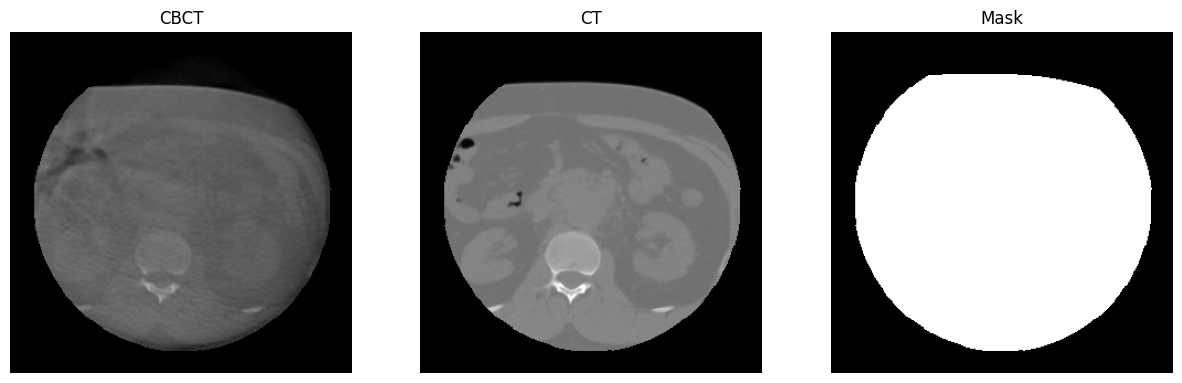

In [16]:
z = cbct_arr.shape[0] // 2

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cbct_arr[z], cmap="gray", vmin=-1000, vmax=1000)
plt.title("CBCT")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ct_arr[z], cmap="gray", vmin=-1000, vmax=1000)
plt.title("CT")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask_arr[z], cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [17]:
os.makedirs("results/figures/dataset_examples", exist_ok=True)

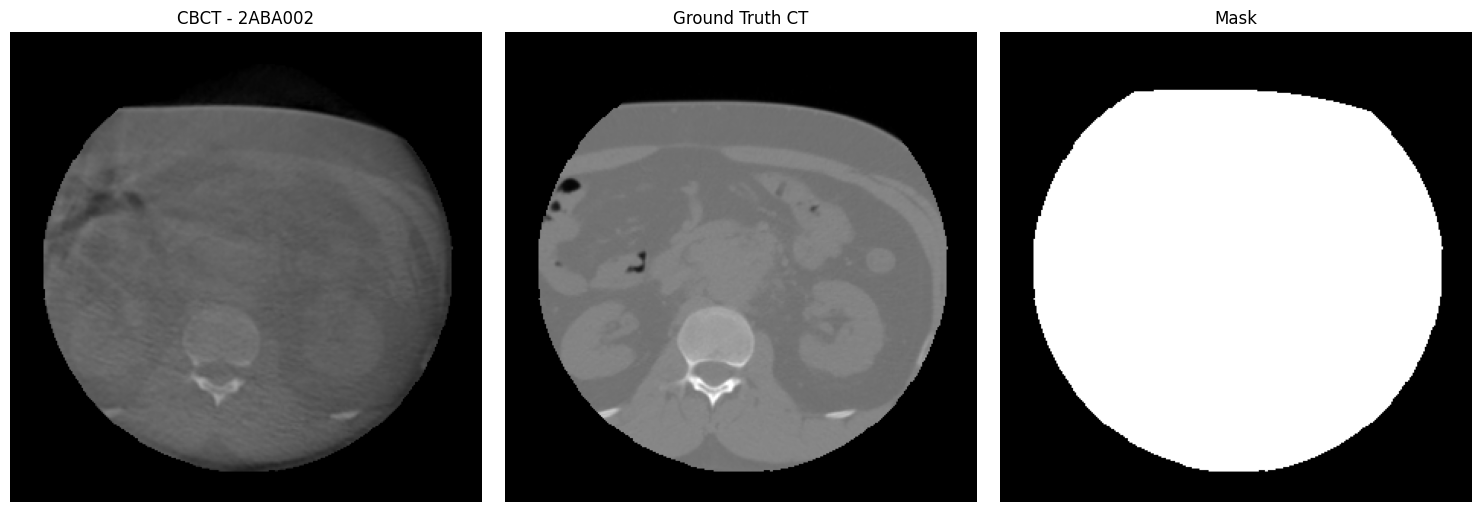

In [18]:
z = cbct_arr.shape[0] // 2

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cbct_arr[z], cmap="gray", vmin=-1000, vmax=1000)
plt.title(f"CBCT - {sample['patient_id']}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ct_arr[z], cmap="gray", vmin=-1000, vmax=1000)
plt.title("Ground Truth CT")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask_arr[z], cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.tight_layout()
plt.savefig("results/figures/dataset_examples/sample_cbct_ct_mask.png", dpi=200)
plt.show()

Region: AB
Patient: 2ABA002
CBCT shape: (88, 309, 310)
CT shape: (88, 309, 310)
CBCT spacing: (1.0, 1.0, 3.0)
CT spacing: (1.0, 1.0, 3.0)
CBCT range: -1024 682
CT range: -1024 1285


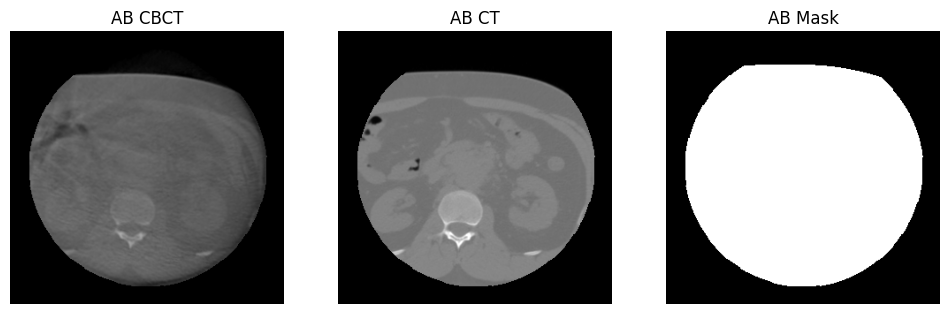

Region: HN
Patient: 2HNA002
CBCT shape: (88, 307, 309)
CT shape: (88, 307, 309)
CBCT spacing: (1.0, 1.0, 3.0)
CT spacing: (1.0, 1.0, 3.0)
CBCT range: -1024 3071
CT range: -1024 3071


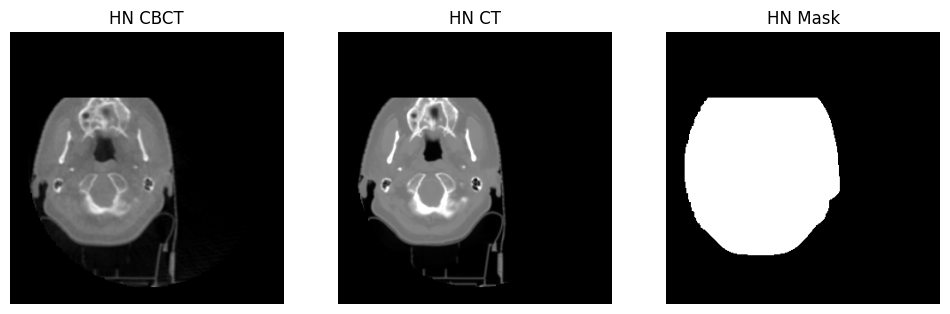

Region: TH
Patient: 2THA005
CBCT shape: (81, 311, 310)
CT shape: (81, 311, 310)
CBCT spacing: (1.0, 1.0, 3.0)
CT spacing: (1.0, 1.0, 3.0)
CBCT range: -1024 469
CT range: -1009 1241


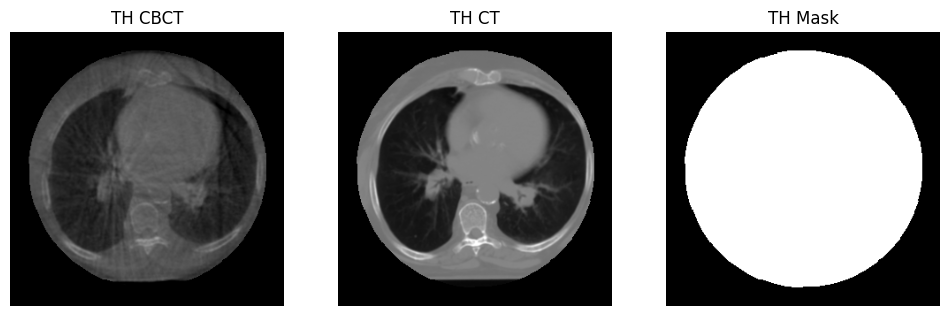

In [19]:
for region in ["AB", "HN", "TH"]:
    sample = df_complete[df_complete["region"] == region].iloc[0]

    cbct_img, cbct_arr, cbct_spacing, _, _ = read_mha(sample["cbct_path"])
    ct_img, ct_arr, ct_spacing, _, _ = read_mha(sample["ct_path"])
    mask_img, mask_arr, mask_spacing, _, _ = read_mha(sample["mask_path"])

    z = cbct_arr.shape[0] // 2

    print("="*50)
    print("Region:", region)
    print("Patient:", sample["patient_id"])
    print("CBCT shape:", cbct_arr.shape)
    print("CT shape:", ct_arr.shape)
    print("CBCT spacing:", cbct_spacing)
    print("CT spacing:", ct_spacing)
    print("CBCT range:", cbct_arr.min(), cbct_arr.max())
    print("CT range:", ct_arr.min(), ct_arr.max())

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(cbct_arr[z], cmap="gray", vmin=-1000, vmax=1000)
    plt.title(f"{region} CBCT")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(ct_arr[z], cmap="gray", vmin=-1000, vmax=1000)
    plt.title(f"{region} CT")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(mask_arr[z], cmap="gray")
    plt.title(f"{region} Mask")
    plt.axis("off")

    plt.show()